In [1]:
from langchain_anthropic import ChatAnthropic
import dotenv
import os

dotenv.load_dotenv()
api_key = os.getenv("ANTHROPIC_API_KEY")
llm = ChatAnthropic(model_name="claude-sonnet-5", api_key=api_key)


In [ ]:
import pandas as pd
from pathlib import Path
df = pd.read_csv(Path.cwd()/"data/MuRAL_for_ML_HAR.csv").drop(columns=["Unnamed: 0"])
df.head()

,time,sensor_status,subject,activity,description,Hour_X,Hour_Y,appliance,location,door_sensor
0,07:22:45,ON,A,bedroom personal activity,"After getting up in the morning, A opens the d...",-0.353271,0.935521,unknown,unknown,bedroom_1_door
1,07:22:49,OFF,A,bedroom personal activity,A walks out of bedroom_1 and then closes the d...,-0.353543,0.935418,unknown,unknown,bedroom_1_door
2,07:22:55,ON,A,using bathroom,"After leaving bedroom_1, A walks into the bath...",-0.353951,0.935264,unknown,bathroom,unknown
3,07:23:04,OFF,A,using bathroom,A starts using the toilet in the bathroom.,-0.354563,0.935032,unknown,bathroom,unknown
4,07:23:16,ON,B,bedroom personal activity,"After getting up in the morning, B opens the d...",-0.355379,0.934722,unknown,unknown,bedroom_1_door


In [7]:
train_df = df.iloc[:int(0.95*len(df))]
test_df = df[int(len(df)*0.95):].reset_index(drop=True)
test_df.head()

,time,sensor_status,subject,activity,description,Hour_X,Hour_Y,appliance,location,door_sensor
0,22:13:28,OFF,"A, B",chatting/using the cell-phone,NaN,0.893894,-0.448279,unknown,dining_room,unknown
1,22:13:51,ON,"A, B",chatting/using the cell-phone,NaN,0.894642,-0.446783,unknown,dining_room,unknown
2,22:13:57,OFF,"A, B",chatting/using the cell-phone,NaN,0.894837,-0.446393,unknown,dining_room,unknown
3,22:14:00,ON,"A, B",chatting/using the cell-phone,NaN,0.894934,-0.446198,unknown,dining_room,unknown
4,22:14:10,OFF,"A, B",chatting/using the cell-phone,NaN,0.895259,-0.445547,unknown,dining_room,unknown


In [8]:
def slice_data(df, output="activity", window_length=10):
    X = []
    x = []
    y = []
    for i in range(len(df) - window_length):
        window = df.iloc[i:i + window_length]
        X.append(window)
        x.append(df.iloc[i + window_length])
        y.append(df.iloc[i + window_length][output])
    return X, x, y

X, x, y = slice_data(df=test_df)

In [9]:
event_sequence_txt = []
sensor_types = ["appliance", "door_sensor", "location"]
for window_id, window in enumerate(X):
    event_seq_txt = ""
    for event_id, event in window.iterrows():
        for sensor_type in sensor_types:
            if event[sensor_type] != 'unknown':
                sensor = sensor_type
                activated_sensor_type = sensor_type
        event_seq_txt += (
            f"At time {event['time']}, Activated sensor: {activated_sensor_type}: {event[sensor_type]} with the status of {event['sensor_status']}. "
            f"Detected activity: {event['activity']}.\n"
        )
    event_sequence_txt.append(event_seq_txt)

event_txt = []
for event in x: 
    event_txt.append(
        f"At time {event['time']}, Activated sensor: {activated_sensor_type}: {event[sensor_type]} with the status of {event['sensor_status']}. "
    )

In [10]:
print(event_sequence_txt[0])

At time 22:13:28, Activated sensor: location: dining_room with the status of OFF. Detected activity: chatting/using the cell-phone.
At time 22:13:51, Activated sensor: location: dining_room with the status of ON. Detected activity: chatting/using the cell-phone.
At time 22:13:57, Activated sensor: location: dining_room with the status of OFF. Detected activity: chatting/using the cell-phone.
At time 22:14:00, Activated sensor: location: dining_room with the status of ON. Detected activity: chatting/using the cell-phone.
At time 22:14:10, Activated sensor: location: dining_room with the status of OFF. Detected activity: chatting/using the cell-phone.
At time 22:14:11, Activated sensor: location: dining_room with the status of ON. Detected activity: chatting/using the cell-phone.
At time 22:14:22, Activated sensor: location: dining_room with the status of OFF. Detected activity: chatting/using the cell-phone.
At time 22:14:23, Activated sensor: location: dining_room with the status of ON

In [11]:
print(event_txt[0])

At time 22:14:31, Activated sensor: door_sensor: dining_room with the status of OFF. 


In [35]:
from typing import TypedDict

class State(TypedDict):
    """State of the agent."""
    event : str
    event_sequence: str
    # ground_truth_activity: str
    detected_activity: str

In [36]:
from langchain_core.prompts import ChatPromptTemplate

def activity_detector(state: State) -> dict:
    prompt_text = """ You are a professional human activity detetor. An eledrly person is living in a house incorporated with PIR sensors for detecting location, 
    smart plugs to detect the activated appliances, and door sensors. 
    You will recieve a sequence of 10 sensor events (On/OFF) and the detected activity of the person associated with the sensors. 
    Your task is to detect the next activity of the person based on the sequence of events from one of the activity labels in the following list.

    0. bedroom personal activity,                     
    1. using bathroom,
    2. preparing breakfast,             
    3. grabing food or drinks,
    4. resting on the couch or the chairs,
    5. having breakfast,                     
    6. washing dishes,
    7. watching TV,                      
    8. reading books,
    9. drinking water, coffee or drinks,                
    10. cleaning appartment,
    11. taking shower,                
    12. playing video games,
    13. getting out of the apartment,          
    14. coming into the apartment,
    15. chatting/using the cell-phone,            
    16. having fruits or snacks,
    17. using pc,                   
    18. preparing dinner,
    19. having dinner,     
    20. playing board games or puzzles,
    21. others, 

    The sensor event sequence and the relevamt activities are: 
    {event_sequence}

    The next sensor event is:
    {event}

    Please make sure to output only the number associated with the predefined activities without any word or symbol.
    """
    prompt = ChatPromptTemplate.from_template(prompt_text)
    chain = prompt | llm
    # Should I set a logger to catch the empty "retrieved_activities"?
    response = chain.invoke({"event_sequence": state["event_sequence"], "event": state.get("event", '')})
    return {** state, "detected_activity": response.content}



In [37]:
from langgraph.graph import END, START, StateGraph

workflow = StateGraph(State)

workflow.add_node("activity_detector", activity_detector)

workflow.add_edge(START, "activity_detector")
workflow.add_edge("activity_detector", END)

Agent = workflow.compile()

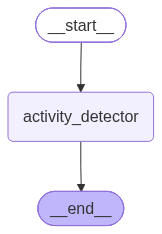

In [38]:
from IPython.display import Image, display

display(Image(Agent.get_graph().draw_mermaid_png()))

Test the Agent. 

In [39]:
rows = []
for n_event_seq, event_seq  in enumerate(event_sequence_txt):
    result = Agent.invoke({
        'event_sequence': event_seq,
        'event': x[n_event_seq]
        })
    rows.append({'event_id': n_event_seq, 'true_activity': y[n_event_seq],
                    'predicted_activity': result["detected_activity"]})
predictions = pd.DataFrame(rows)
y_true = predictions['true_activity']
y_pred = predictions['predicted_activity']

In [ ]:
y_pred.to_csv(Path.cwd()/"results/Agent_preditions.csv")

In [45]:
activity_map = {
    "0": "bedroom personal activity",
    "1": "using bathroom",
    "2": "preparing breakfast",             
    "3": "grabing food or drinks",
    "4": "resting on the couch or the chairs",
    "5": "having breakfast",     
    "6": "washing dishes",
    "7": "watching TV",                      
    "8": "reading books",
    "9": "drinking water, coffee or drinks",                
    "10": "cleaning appartment",
    "11": "taking shower",                
    "12": "playing video games",
    "13": "getting out of the apartment",          
    "14": "coming into the apartment",
    "15": "chatting/using the cell-phone",            
    "16": "having fruits or snacks",
    "17": "using pc",      
    "18": "preparing dinner",
    "19": "having dinner",     
    "20": "playing board games or puzzles",
    "21": "others", 
}
y_pred_labels = y_pred.astype(str).map(activity_map)
y_pred_labels

0      chatting/using the cell-phone
1      chatting/using the cell-phone
2      chatting/using the cell-phone
3      chatting/using the cell-phone
4      chatting/using the cell-phone
                   ...              
417        bedroom personal activity
418        bedroom personal activity
419    chatting/using the cell-phone
420        bedroom personal activity
421        bedroom personal activity
Name: predicted_activity, Length: 422, dtype: str

In [46]:
y_true

0      chatting/using the cell-phone
1      chatting/using the cell-phone
2      chatting/using the cell-phone
3      chatting/using the cell-phone
4      chatting/using the cell-phone
                   ...              
417                   using bathroom
418                           others
419                           others
420        bedroom personal activity
421        bedroom personal activity
Name: true_activity, Length: 422, dtype: str

In [53]:
def _classification_summary(y_true, y_pred, labels):
    records = []
    for label in labels:
        tp = int(((y_true == label) & (y_pred == label)).sum())
        fp = int(((y_true != label) & (y_pred == label)).sum())
        fn = int(((y_true == label) & (y_pred != label)).sum())
        precision = tp / (tp + fp) if tp + fp else 0.0
        recall = tp / (tp + fn) if tp + fn else 0.0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
        records.append({'activity': label, 'precision': precision, 'recall': recall,
                        'f1': f1, 'support': int((y_true == label).sum())})
    return pd.DataFrame(records)

In [ ]:
report = _classification_summary(y_true, y_pred_labels, sorted(y_true.dropna().unique().tolist()))
metrics = {
    'n_tested': len(predictions),
    'accuracy': float((y_true == y_pred_labels).mean()),
    'macro_f1': float(report['f1'].mean()),
    'invalid_or_error_rate': float(predictions['predicted_activity'].isna().mean()),
    'report': report,
}

In [59]:
metrics

{'n_tested': 422,
 'accuracy': 0.8981042654028436,
 'macro_f1': 0.7507939279830266,
 'invalid_or_error_rate': 0.0,
 'report':                               activity  precision    recall        f1  support
 0            bedroom personal activity   0.806452  0.757576  0.781250       33
 1        chatting/using the cell-phone   0.943396  0.990099  0.966184      101
 2               grabing food or drinks   0.839286  0.854545  0.846847       55
 3              having fruits or snacks   1.000000  0.500000  0.666667        2
 4                               others   0.000000  0.000000  0.000000        2
 5                  playing video games   0.978261  0.927835  0.952381       97
 6                        reading books   0.833333  0.937500  0.882353       16
 7   resting on the couch or the chairs   0.821429  0.958333  0.884615       24
 8                        taking shower   1.000000  0.250000  0.400000        4
 9                       using bathroom   0.869565  0.689655  0.769231     